# 03 · Uncertainty: do prediction intervals stay calibrated?

**Question (RQ2).** When point forecasts are about as good as persistence, what remains useful is
a *calibrated statement of uncertainty*. Do intervals keep their nominal coverage when
volatility changes, and does sequential calibration help?

**Intervals are built around the validation-selected forecast** (which may be persistence itself)
for the 80% and 95% levels, per horizon.

| Method | Calibration |
| --- | --- |
| `gaussian_vol` | `± z · σ_EWMA · √h`, no calibration data |
| `static_abs` | split conformal, absolute residuals from the validation segment, never updated |
| `rolling_abs` | same, using the latest 500 realised residuals |
| `static_norm` / `rolling_norm` | as above on residuals divided by `σ_EWMA · √h` |
| `aci_norm` | adaptive conformal inference (Gibbs & Candès, 2021) on normalised residuals |

**No look-ahead.** An outcome enters calibration only once it is realised: the score of origin
`j` is usable at origin `k` only if `j + h <= k`. Validation scores are all realised before the first
test origin. Metrics: empirical coverage, mean width, interval (Winkler) score, coverage by
volatility regime (terciles taken from the validation segment) and by calendar year.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from tsresearch.workspace import load_studies

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

studies = load_studies()
for s in studies:
    kind = "SYNTHETIC DEMO" if s.demo else "real data"
    print(f"{s.name:5s} [{kind}]  {len(s.dataset)} rows  {s.dataset.dates[0].date()} -> "
          f"{s.dataset.dates[-1].date()}  sha256={s.dataset.sha256[:12]}...")
if any(s.demo for s in studies):
    print("\nDEMO MODE: real files not found in data/raw/, so synthetic data is used. "
          "Numbers differ from the committed real-data run.")

VN30  [real data]  4426 rows  2009-01-05 -> 2026-09-28  sha256=1b91f9f2d89a...
BID   [real data]  3153 rows  2014-01-27 -> 2026-09-24  sha256=918ad0197245...


In [2]:
from tsresearch.backtest import run_specs
from tsresearch.metrics import mase_scale, point_metrics
from tsresearch.models import spec_name
from tsresearch.selection import CANDIDATE_SPECS, choose_models
from tsresearch.uncertainty import (LABELS, METHODS, build_intervals, coverage_by_regime,
                                    summarise_intervals)
from tsresearch.conformal import rolling_mean

centres = {}
for s in studies:
    val_all = run_specs(s.dataset, CANDIDATE_SPECS, s.protocol, "validation", cache_dir=s.cache_dir)
    chosen = choose_models(point_metrics(val_all, mase_scale(s.dataset, s.protocol)))
    needed = {spec_name(chosen["center"]): chosen["center"],
              spec_name(chosen["best_learned"]): chosen["best_learned"]}
    test_pred = run_specs(s.dataset, list(needed.values()), s.protocol, "test",
                          cache_dir=s.cache_dir)
    centres[s.name] = {"chosen": chosen, "validation": val_all, "test": test_pred}
    print(f"{s.name}: interval centre = {spec_name(chosen['center'])}; "
          f"best learned model = {spec_name(chosen['best_learned'])}")

VN30: interval centre = naive; best learned model = extra_trees(min_leaf=60)


BID: interval centre = extra_trees(min_leaf=20); best learned model = extra_trees(min_leaf=20)


## 1. Coverage, width and interval score on the test segment

In [3]:
results = {}
for s in studies:
    c = centres[s.name]
    name = spec_name(c["chosen"]["center"])
    val = c["validation"][c["validation"]["model"] == name]
    tst = c["test"][c["test"]["model"] == name]
    intervals = build_intervals(val, tst)
    summary = summarise_intervals(intervals)
    results[s.name] = {"intervals": intervals, "summary": summary, "val": val, "name": name}
    s.save_table(summary, "03_interval_summary")
    print(f"== {s.name} (centre: {name}); test origins per cell: {summary['n'].iloc[0]}")
    for value, title in (("coverage", "Empirical coverage (target in the column header)"),
                         ("mean_width", "Mean interval width (log-return units)"),
                         ("interval_score", "Interval score (lower is better)")):
        table = summary.pivot_table(index="method", columns=["nominal", "horizon"], values=value)
        table = table.loc[list(METHODS)].rename(index=LABELS)
        print(title)
        display(table.round(4))

== VN30 (centre: naive); test origins per cell: 912
Empirical coverage (target in the column header)


nominal                                             0.80                    0.95                
horizon                                               1       5       20      1       5       20
method                                                                                          
Gaussian, EWMA volatility (no calibration)        0.8322  0.8015  0.7862  0.9408  0.9287  0.9002
Split conformal, absolute residuals (static)      0.8520  0.8640  0.8761  0.9792  0.9846  0.9879
Split conformal, absolute residuals (rolling)     0.8224  0.8136  0.8059  0.9518  0.9627  0.9298
Split conformal, volatility-normalised (static)   0.8147  0.8279  0.8136  0.9550  0.9682  0.9923
Split conformal, volatility-normalised (rolling)  0.8070  0.8081  0.7906  0.9583  0.9572  0.9649
Adaptive conformal (ACI), volatility-normalised   0.8015  0.7993  0.8015  0.9496  0.9485  0.9485

Mean interval width (log-return units)


nominal                                             0.80                    0.95                
horizon                                               1       5       20      1       5       20
method                                                                                          
Gaussian, EWMA volatility (no calibration)        0.0294  0.0657  0.1314  0.0449  0.1005  0.2009
Split conformal, absolute residuals (static)      0.0297  0.0742  0.1607  0.0637  0.1402  0.2655
Split conformal, absolute residuals (rolling)     0.0268  0.0662  0.1356  0.0551  0.1155  0.2484
Split conformal, volatility-normalised (static)   0.0280  0.0706  0.1433  0.0495  0.1188  0.3128
Split conformal, volatility-normalised (rolling)  0.0278  0.0670  0.1375  0.0499  0.1127  0.2884
Adaptive conformal (ACI), volatility-normalised   0.0271  0.0664  0.1592  0.0495  0.1099  0.3053

Interval score (lower is better)


...

nominal                                             0.80                    0.95                
horizon                                               1       5       20      1       5       20
method                                                                                          
Gaussian, EWMA volatility (no calibration)        0.8376  0.8243  0.7812  0.9370  0.9381  0.9182
Split conformal, absolute residuals (static)      0.8928  0.9105  0.8829  0.9790  0.9845  0.9646
Split conformal, absolute residuals (rolling)     0.8309  0.8475  0.8365  0.9624  0.9569  0.9403
Split conformal, volatility-normalised (static)   0.8298  0.8210  0.7834  0.9580  0.9624  0.9492
Split conformal, volatility-normalised (rolling)  0.8099  0.8066  0.7834  0.9536  0.9425  0.9414
Adaptive conformal (ACI), volatility-normalised   0.8011  0.7978  0.7945  0.9503  0.9470  0.9470

Mean interval width (log-return units)


nominal                                             0.80                    0.95                
horizon                                               1       5       20      1       5       20
method                                                                                          
Gaussian, EWMA volatility (no calibration)        0.0431  0.0963  0.1926  0.0659  0.1473  0.2945
Split conformal, absolute residuals (static)      0.0499  0.1218  0.2271  0.1062  0.1957  0.4184
Split conformal, absolute residuals (rolling)     0.0413  0.0977  0.2022  0.0895  0.1587  0.3403
Split conformal, volatility-normalised (static)   0.0422  0.0960  0.1980  0.0758  0.1674  0.3933
Split conformal, volatility-normalised (rolling)  0.0400  0.0928  0.2012  0.0750  0.1598  0.3929
Adaptive conformal (ACI), volatility-normalised   0.0398  0.0920  0.2198  0.0739  0.1983  0.6412

Interval score (lower is better)


nominal                                             0.80                    0.95                
horizon                                               1       5       20      1       5       20
method                                                                                          
Gaussian, EWMA volatility (no calibration)        0.0619  0.1384  0.3069  0.0984  0.2233  0.5255
Split conformal, absolute residuals (static)      0.0664  0.1464  0.2996  0.1158  0.2326  0.4864
Split conformal, absolute residuals (rolling)     0.0646  0.1405  0.3063  0.1149  0.2258  0.5430
Split conformal, volatility-normalised (static)   0.0617  0.1383  0.3076  0.0982  0.2287  0.5374
Split conformal, volatility-normalised (rolling)  0.0616  0.1389  0.3117  0.0986  0.2323  0.5631
Adaptive conformal (ACI), volatility-normalised   0.0616  0.1402  0.3239  0.0995  0.2639  0.7310

## 2. Rolling coverage over the test period

Share of the last 250 origins covered, for h = 5. The dashed line is the nominal level.

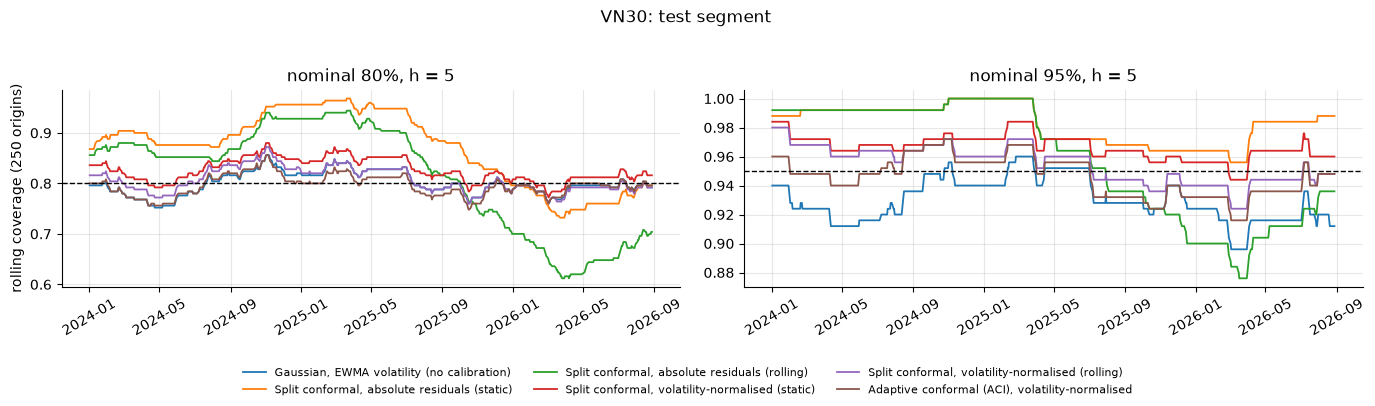

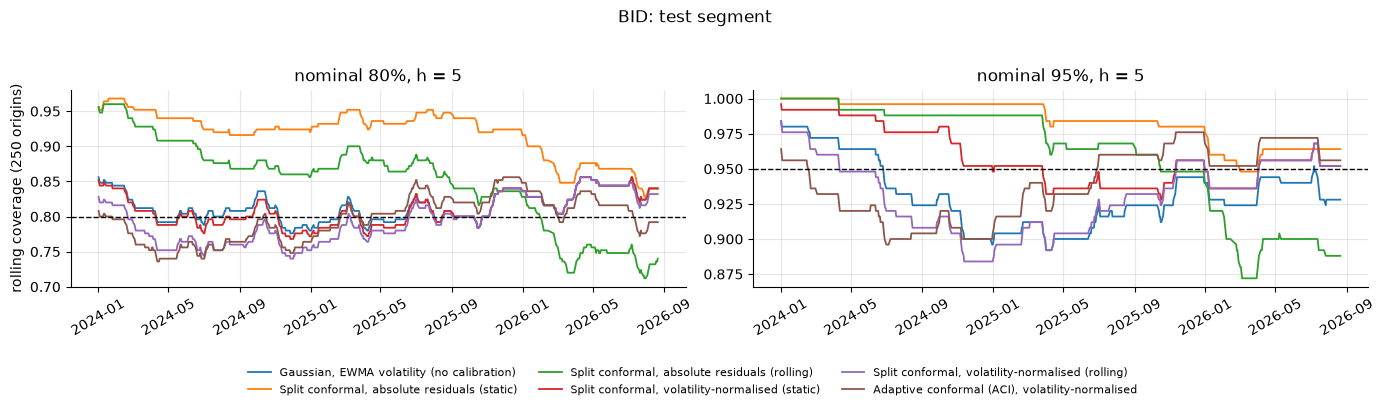

In [4]:
WINDOW = 250
H = 5
for s in studies:
    intervals = results[s.name]["intervals"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
    for ax, alpha in zip(axes, (0.2, 0.05)):
        for method in METHODS:
            g = intervals[(intervals["method"] == method) & (intervals["horizon"] == H)
                          & (intervals["alpha"] == alpha)].sort_values("origin")
            hit = ((g["actual"] >= g["lower"]) & (g["actual"] <= g["upper"])).to_numpy(float)
            ax.plot(g["origin_date"].iloc[WINDOW - 1:].to_numpy(), rolling_mean(hit, WINDOW),
                    label=LABELS[method], lw=1.3)
        ax.axhline(1 - alpha, color="k", ls="--", lw=1)
        ax.set_title(f"nominal {1 - alpha:.0%}, h = {H}")
        ax.tick_params(axis="x", rotation=30)
    axes[0].set_ylabel("rolling coverage (250 origins)")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=8, frameon=False)
    fig.suptitle(f"{s.name}: test segment")
    fig.tight_layout(rect=(0, 0.12, 1, 0.95))
    s.save_figure(fig, "03_rolling_coverage")
    plt.show()

## 3. What the intervals look like

Last 250 test origins, h = 1, 95% adaptive intervals against realised one-session log returns.

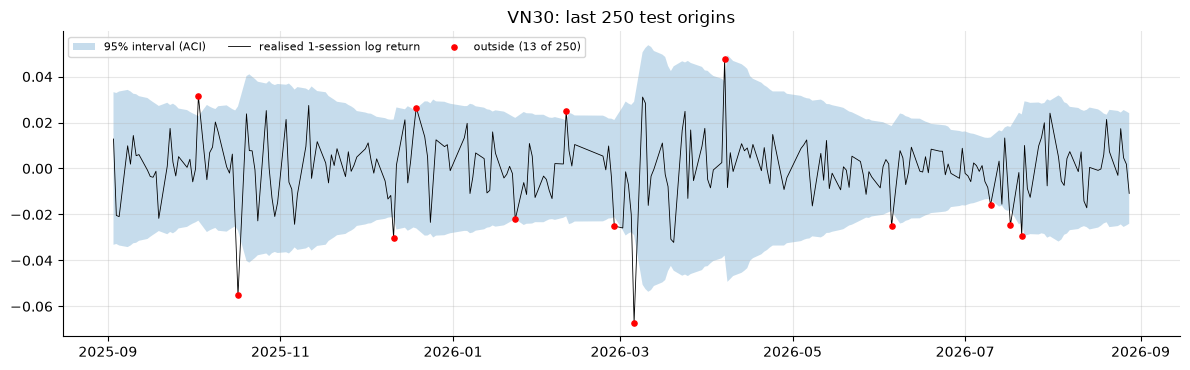

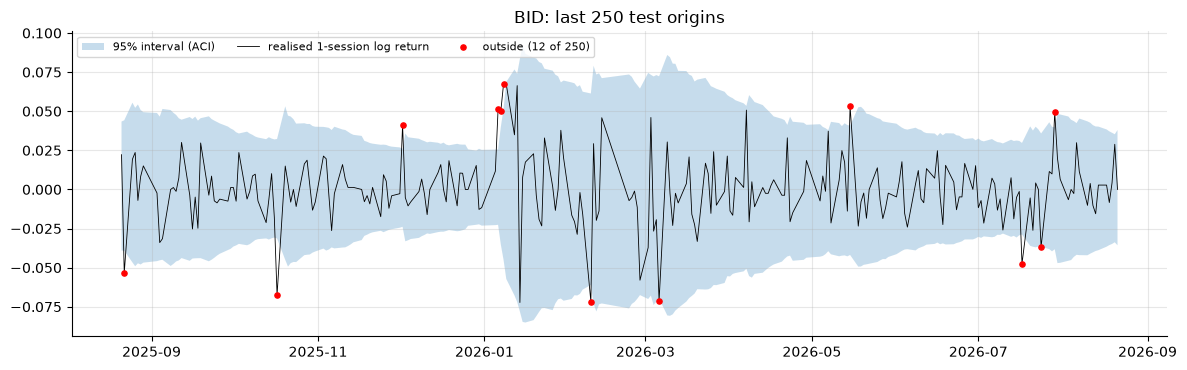

In [5]:
for s in studies:
    intervals = results[s.name]["intervals"]
    g = intervals[(intervals["method"] == "aci_norm") & (intervals["horizon"] == 1)
                  & (intervals["alpha"] == 0.05)].sort_values("origin").tail(250)
    outside = (g["actual"] < g["lower"]) | (g["actual"] > g["upper"])
    fig, ax = plt.subplots(figsize=(12, 3.8))
    ax.fill_between(g["origin_date"], g["lower"], g["upper"], alpha=0.25, label="95% interval (ACI)")
    ax.plot(g["origin_date"], g["actual"], lw=0.6, color="k", label="realised 1-session log return")
    ax.scatter(g["origin_date"][outside], g["actual"][outside], color="r", s=14, zorder=3,
               label=f"outside ({int(outside.sum())} of {len(g)})")
    ax.legend(fontsize=8, ncol=3, loc="upper left")
    ax.set_title(f"{s.name}: last 250 test origins")
    fig.tight_layout()
    s.save_figure(fig, "03_interval_example")
    plt.show()

## 4. Coverage by volatility regime and by year

Regimes use the 1/3 and 2/3 quantiles of trailing volatility **in the validation segment**. Conditional coverage is the harder requirement: static intervals tend to over-cover calm periods and under-cover turbulent ones.

In [6]:
for s in studies:
    r = results[s.name]
    edges = tuple(np.quantile(r["val"][r["val"]["horizon"] == 1]["vol_ewma"], [1 / 3, 2 / 3]))
    regimes = coverage_by_regime(r["intervals"], edges)
    s.save_table(regimes, "03_coverage_by_regime")
    print(f"== {s.name}, h = 5 (volatility edges {edges[0]:.4f}, {edges[1]:.4f})")
    table = regimes[regimes["horizon"] == 5].pivot_table(
        index="method", columns=["nominal", "regime"], values="coverage")
    order = [(n, g) for n in (0.8, 0.95) for g in ("low vol", "mid vol", "high vol")]
    display(table.loc[list(METHODS), order].rename(index=LABELS).round(3))
    share = r["intervals"].query("method == 'aci_norm' and horizon == 5 and alpha == 0.2")
    labels = np.where(share["vol_ewma"] <= edges[0], "low vol",
                      np.where(share["vol_ewma"] <= edges[1], "mid vol", "high vol"))
    print("share of test origins by regime:", pd.Series(labels).value_counts(normalize=True)
          .round(3).to_dict())

== VN30, h = 5 (volatility edges 0.0097, 0.0141)


nominal                                             0.80                     0.95                 
regime                                           low vol mid vol high vol low vol mid vol high vol
method                                                                                            
Gaussian, EWMA volatility (no calibration)         0.731   0.806    0.914   0.894   0.930    0.986
Split conformal, absolute residuals (static)       0.930   0.835    0.800   0.986   0.988    0.976
Split conformal, absolute residuals (rolling)      0.908   0.777    0.714   0.978   0.957    0.948
Split conformal, volatility-normalised (static)    0.768   0.829    0.929   0.944   0.974    1.000
Split conformal, volatility-normalised (rolling)   0.737   0.814    0.919   0.930   0.962    0.995
Adaptive conformal (ACI), volatility-normalised    0.714   0.809    0.929   0.905   0.965    0.995

share of test origins by regime: {'low vol': 0.391, 'mid vol': 0.378, 'high vol': 0.23}
== BID, h = 5 (volatility edges 0.0172, 0.0239)


nominal                                             0.80                     0.95                 
regime                                           low vol mid vol high vol low vol mid vol high vol
method                                                                                            
Gaussian, EWMA volatility (no calibration)         0.756   0.942    0.905   0.905   0.988    0.991
Split conformal, absolute residuals (static)       0.914   0.950    0.810   0.984   0.996    0.966
Split conformal, absolute residuals (rolling)      0.854   0.900    0.707   0.967   0.975    0.871
Split conformal, volatility-normalised (static)    0.750   0.942    0.905   0.940   0.996    1.000
Split conformal, volatility-normalised (rolling)   0.730   0.933    0.905   0.907   0.996    1.000
Adaptive conformal (ACI), volatility-normalised    0.723   0.933    0.871   0.914   0.996    1.000

share of test origins by regime: {'low vol': 0.607, 'mid vol': 0.265, 'high vol': 0.128}


In [7]:
for s in studies:
    g = results[s.name]["intervals"].query("horizon == 5 and alpha == 0.2").copy()
    g["hit"] = (g["actual"] >= g["lower"]) & (g["actual"] <= g["upper"])
    by_year = g.groupby([g["origin_date"].dt.year.rename("year"), "method"])["hit"].mean()
    table = by_year.unstack("method")[list(METHODS)].rename(columns=LABELS)
    print(f"== {s.name}: 80% coverage by calendar year, h = 5")
    display(table.round(3))

== VN30: 80% coverage by calendar year, h = 5


method,"Gaussian, EWMA volatility (no calibration)","Split conformal, absolute residuals (static)","Split conformal, absolute residuals (rolling)","Split conformal, volatility-normalised (static)","Split conformal, volatility-normalised (rolling)","Adaptive conformal (ACI), volatility-normalised"
year,,,,,,
2023,0.795,0.867,0.855,0.835,0.815,0.799
2024,0.820,0.956,0.928,0.844,0.824,0.804
2025,0.791,0.795,0.699,0.807,0.791,0.791
2026,0.799,0.823,0.750,0.823,0.799,0.805


== BID: 80% coverage by calendar year, h = 5

method,"Gaussian, EWMA volatility (no calibration)","Split conformal, absolute residuals (static)","Split conformal, absolute residuals (rolling)","Split conformal, volatility-normalised (static)","Split conformal, volatility-normalised (rolling)","Adaptive conformal (ACI), volatility-normalised"
year,,,,,,
2023,0.859,0.960,0.960,0.855,0.831,0.811
2024,0.780,0.920,0.856,0.772,0.752,0.764
2025,0.839,0.920,0.831,0.839,0.839,0.851
2026,0.815,0.803,0.682,0.815,0.803,0.745


## 5. Sensitivity of adaptive conformal inference

Step size `gamma` and calibration window for `aci_norm` at h = 5. Larger `gamma` reacts faster but widens or narrows the interval more violently.

In [8]:
rows = []
for s in studies:
    r = results[s.name]
    c = centres[s.name]
    tst = c["test"][c["test"]["model"] == r["name"]]
    for gamma in (0.001, 0.005, 0.02):
        for window in (250, 500, 1000):
            iv = build_intervals(r["val"], tst, alphas=(0.2, 0.05), window=window, gamma=gamma)
            iv = iv[(iv["method"] == "aci_norm") & (iv["horizon"] == 5)]
            for row in summarise_intervals(iv).itertuples():
                rows.append({"dataset": s.name, "gamma": gamma, "window": window,
                             "nominal": row.nominal, "coverage": row.coverage,
                             "mean_width": row.mean_width, "interval_score": row.interval_score})
sensitivity = pd.DataFrame(rows)
display(sensitivity.pivot_table(index=["dataset", "gamma", "window"], columns="nominal",
                                values=["coverage", "mean_width"]).round(4))
for s in studies:
    s.save_table(sensitivity[sensitivity["dataset"] == s.name], "03_aci_sensitivity")

coverage         mean_width        
nominal                  0.80    0.95       0.80    0.95
dataset gamma window                                    
BID     0.001 250      0.8033  0.9448     0.0918  0.1760
              500      0.8033  0.9392     0.0922  0.1656
              1000     0.8033  0.9436     0.0919  0.1570
        0.005 250      0.7956  0.9481     0.0933  0.2077
              500      0.7978  0.9470     0.0920  0.1983
              1000     0.7956  0.9459     0.0917  0.1653
        0.020 250      0.7967  0.9470     0.0923  0.2802
              500      0.7978  0.9470     0.0923  0.3059
              1000     0.7967  0.9459     0.0926  0.2931
VN30    0.001 250      0.8059  0.9561     0.0684  0.1136
              500      0.8037  0.9518     0.0666  0.1101
              1000     0.8070  0.9529     0.0666  0.1103
        0.005 250      0.8015  0.9507     0.0680  0.1167
              500      0.7993  0.9485     0.0664  0.1099
              1000     0.7982  0.9485     0.0671  0.1104
        0.020 250      0.7982  0.9485     0.0704  0.1941
              500      0.7982  0.9474     0.0705  0.2191
              1000     0.7982  0.9474     0.0690  0.2073

## 6. Does the centre of the interval matter?

Adaptive intervals around persistence versus around the best learned model (chosen on validation).

In [9]:
rows = []
for s in studies:
    c = centres[s.name]
    for model in sorted({spec_name(c["chosen"]["center"]), spec_name(c["chosen"]["best_learned"])}):
        val = c["validation"][c["validation"]["model"] == model]
        tst = c["test"][c["test"]["model"] == model]
        iv = build_intervals(val, tst)
        iv = iv[iv["method"] == "aci_norm"]
        for row in summarise_intervals(iv).itertuples():
            rows.append({"dataset": s.name, "centre": model, "horizon": row.horizon,
                         "nominal": row.nominal, "coverage": row.coverage,
                         "mean_width": row.mean_width, "interval_score": row.interval_score})
centre_table = pd.DataFrame(rows)
display(centre_table.pivot_table(index=["dataset", "centre"], columns=["nominal", "horizon"],
                                 values="interval_score").round(4))
for s in studies:
    s.save_table(centre_table[centre_table["dataset"] == s.name], "03_centre_comparison")

nominal                             0.80                    0.95                
horizon                               1       5       20      1       5       20
dataset centre                                                                  
BID     extra_trees(min_leaf=20)  0.0616  0.1402  0.3239  0.0995  0.2639  0.7310
VN30    extra_trees(min_leaf=60)  0.0419  0.0954  0.1993  0.0685  0.1495  0.3163
        naive                     0.0420  0.0957  0.2128  0.0685  0.1476  0.3437

### Findings (committed run)

* **Adaptive conformal inference (ACI) gives the best marginal coverage.** Across horizons and
  both datasets its empirical coverage is within about 0.01 of the 80% and 95% targets
  (VN30 0.799-0.802 and 0.948-0.950; BID 0.794-0.801 and 0.947-0.950).
* **Static split conformal over-covers on the test segment** (VN30 0.85-0.88 at the 80% level,
  BID 0.88-0.91) because the validation period (2018-2022, including two stress episodes) was
  more turbulent than the test period. Intervals calibrated once are too wide when conditions
  calm down; this is the regime-shift problem that motivates sequential calibration.
* **The uncalibrated Gaussian EWMA interval under-covers at long horizons**
  (95% level at h = 20: 0.900 for VN30, 0.918 for BID), i.e. scaling one-day volatility by
  `sqrt(h)` understates multi-day risk.
* **Marginal coverage is not conditional coverage.** Within volatility regimes (h = 5, 80%
  level) the volatility-normalised methods under-cover calm periods (0.71-0.73 for ACI on VN30
  and BID) and over-cover turbulent ones (0.93 and 0.87); the un-normalised rolling method
  errs in the opposite direction (0.71 in high volatility on both). Normalising by the full
  EWMA volatility therefore over-corrects: the scale of the errors rises less than
  proportionally with trailing volatility. A better-calibrated scale function is a concrete
  next step.
* **Interval score and calibration rank methods differently at long horizons.** At h = 1 the
  ACI and Gaussian interval scores are within 2% of each other on both datasets, but the gap
  opens with the horizon: at the 95% level ACI scores 0.344 (VN30) and 0.731 (BID) at h = 20
  against 0.287 and 0.526 for the Gaussian interval, and static conformal on VN30 scores
  0.273. Exact coverage is not free.
* **The centre matters little at short horizons.** On VN30, intervals around persistence and
  around the best learned model (extra-trees) have the same score at h = 1 (0.0420 vs 0.0419 at
  80%), while at h = 20 the extra-trees centre scores lower (0.199 vs 0.213 at 80%; 0.316 vs
  0.344 at 95%). On BID the validation-selected centre is itself the best learned model, so
  that comparison is not informative there.

Limits: one test period per dataset, overlapping targets, a heuristic delayed-feedback ACI
update (no formal guarantee is claimed), and a single stock plus one index.